In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import pywt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 23,
    "axes.titlesize": 25,
    "axes.labelsize": 23,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 20,
})

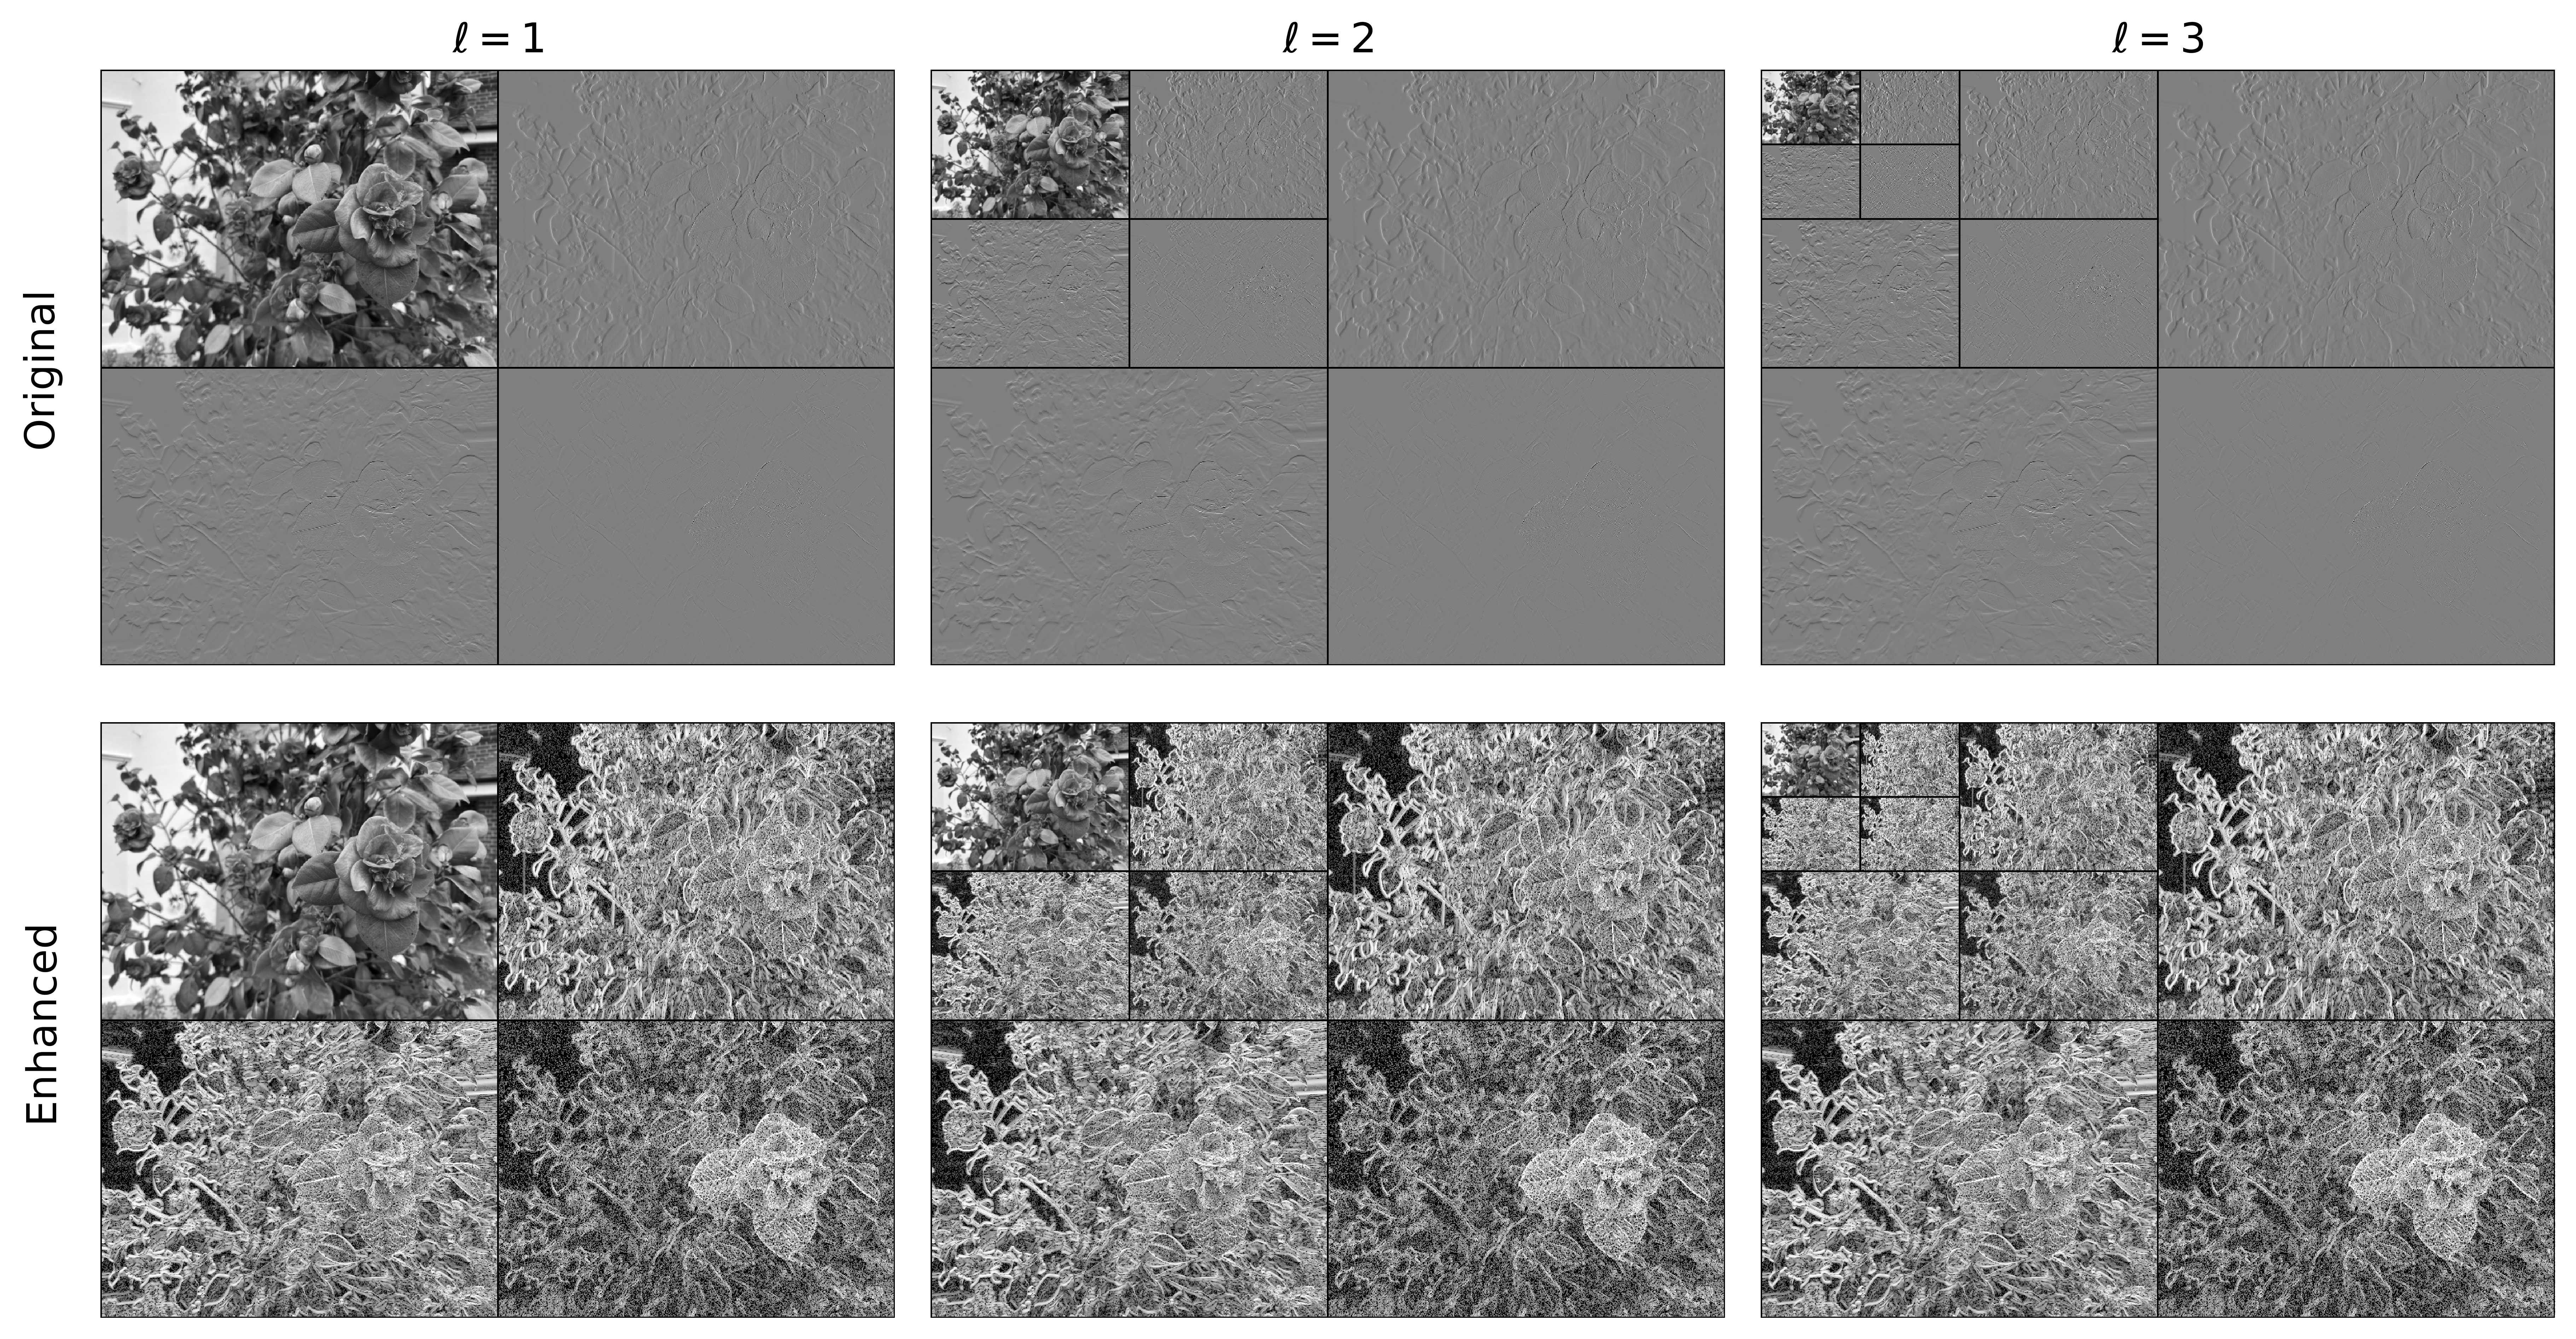

In [ ]:
def resize_keep_aspect(pil_img, max_dim=1024):
    w, h = pil_img.size
    scale = min(max_dim / max(w, h), 1.0)
    new_size = (int(w * scale), int(h * scale))
    return pil_img.resize(new_size, Image.LANCZOS)

def normalise_01(x):
    x = np.asarray(x, dtype=float)
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        return np.zeros_like(x)
    return (x - xmin) / (xmax - xmin)

def contrast_boost(x, factor=1.8):
    x = np.asarray(x, dtype=float)
    return np.clip(0.5 + factor * (x - 0.5), 0, 1)

def detail_to_display_original(block):

    block = np.asarray(block, dtype=float)
    m = np.max(np.abs(block))
    if m == 0:
        return np.full_like(block, 0.5)
    return 0.5 + 0.5 * block / m

def build_display_array_original(arr, coeff_slices):
    vis = np.full(arr.shape, 0.5, dtype=float)

    vis[coeff_slices[0]] = normalise_01(arr[coeff_slices[0]])

    for level_slices in coeff_slices[1:]:
        for sl in level_slices.values():
            vis[sl] = detail_to_display_original(arr[sl])

    return vis

def approx_to_display_enhanced(block, gamma=0.9):
    y = normalise_01(block)
    return np.power(y, gamma)

def detail_to_display_enhanced(block, percentile=99.5, strength=350.0):

    mag = np.abs(np.asarray(block, dtype=float))
    scale = np.percentile(mag, percentile)

    if scale <= 1e-12:
        return np.zeros_like(mag)

    y = np.log1p(strength * mag / scale) / np.log1p(strength)
    return np.clip(y, 0, 1)

def build_display_array_enhanced(arr, coeff_slices, contrast_factor=1.05):
    vis = np.zeros(arr.shape, dtype=float)

    vis[coeff_slices[0]] = approx_to_display_enhanced(arr[coeff_slices[0]])

    for level_slices in coeff_slices[1:]:
        for sl in level_slices.values():
            vis[sl] = detail_to_display_enhanced(arr[sl])

    m = vis.mean()
    vis = np.clip(m + contrast_factor * (vis - m), 0, 1)

    return vis

def slice_bounds(s, n):

    start = 0 if s.start is None else s.start
    stop = n if s.stop is None else s.stop
    return start, stop

def draw_slice_box(ax, sl, shape, lw=1.2, colour="black"):
    row_sl, col_sl = sl
    h, w = shape

    row_start, row_stop = slice_bounds(row_sl, h)
    col_start, col_stop = slice_bounds(col_sl, w)

    x = col_start - 0.5
    y = row_start - 0.5
    width = col_stop - col_start
    height = row_stop - row_start

    rect = Rectangle(
        (x, y), width, height,
        fill=False,
        edgecolor=colour,
        linewidth=lw
    )
    ax.add_patch(rect)

def draw_decomposition_boxes(ax, coeff_slices, shape):

    h, w = shape


    ax.add_patch(Rectangle(
        (-0.5, -0.5), w, h,
        fill=False, edgecolor="black", linewidth=0.85
    ))

    draw_slice_box(ax, coeff_slices[0], shape, lw=0.55)

    for i, level_slices in enumerate(coeff_slices[1:], start=1):
        lw = max(0.40, 0.60 - 0.05 * (i - 1))
        for sl in level_slices.values():
            draw_slice_box(ax, sl, shape, lw=lw)



img_path = "/Users/jobryen/Documents/GitHub/essaycompressor/compress_test.tmp/IMG_5419.tiff"
img_pil = Image.open(img_path).convert("L")
img_pil = resize_keep_aspect(img_pil, max_dim=1024)

img = np.asarray(img_pil, dtype=float) / 255.0

wavelet = "haar"
mode = "periodization"

max_level = pywt.dwtn_max_level(img.shape, wavelet)
levels = [l for l in [1, 2, 3] if l <= max_level]


def decomposition(level, display_builder):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level, mode=mode)
    arr, coeff_slices = pywt.coeffs_to_array(coeffs)
    vis = display_builder(arr, coeff_slices)
    return vis, coeff_slices

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=600)
fig.patch.set_facecolor("white")

for j in range(3):
    if j < len(levels):
        level = levels[j]



        vis_orig, coeff_slices_orig = decomposition(level, build_display_array_original)
        axes[0, j].imshow(
            vis_orig,
            cmap="gray",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )
        draw_decomposition_boxes(axes[0, j], coeff_slices_orig, vis_orig.shape)
        axes[0, j].set_title(rf"$\ell = {level}$", fontsize=14)
        axes[0, j].axis("off")


        vis_enh, coeff_slices_enh = decomposition(level, build_display_array_enhanced)
        axes[1, j].imshow(
            vis_enh,
            cmap="gray",
            vmin=0,
            vmax=1,
            interpolation="nearest"
        )
        draw_decomposition_boxes(axes[1, j], coeff_slices_enh, vis_enh.shape)
        axes[1, j].axis("off")

    else:
        axes[0, j].axis("off")
        axes[1, j].axis("off")

axes[0, 0].text(
    -0.075, 0.5, "Original",
    rotation=90, va="center", ha="center",
    fontsize=14, transform=axes[0, 0].transAxes
)

axes[1, 0].text(
    -0.075, 0.5, "Enhanced",
    rotation=90, va="center", ha="center",
    fontsize=14, transform=axes[1, 0].transAxes
)

plt.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.92,
    bottom=0.06,
    wspace=0.045,
    hspace=0.045
)

plt.show()

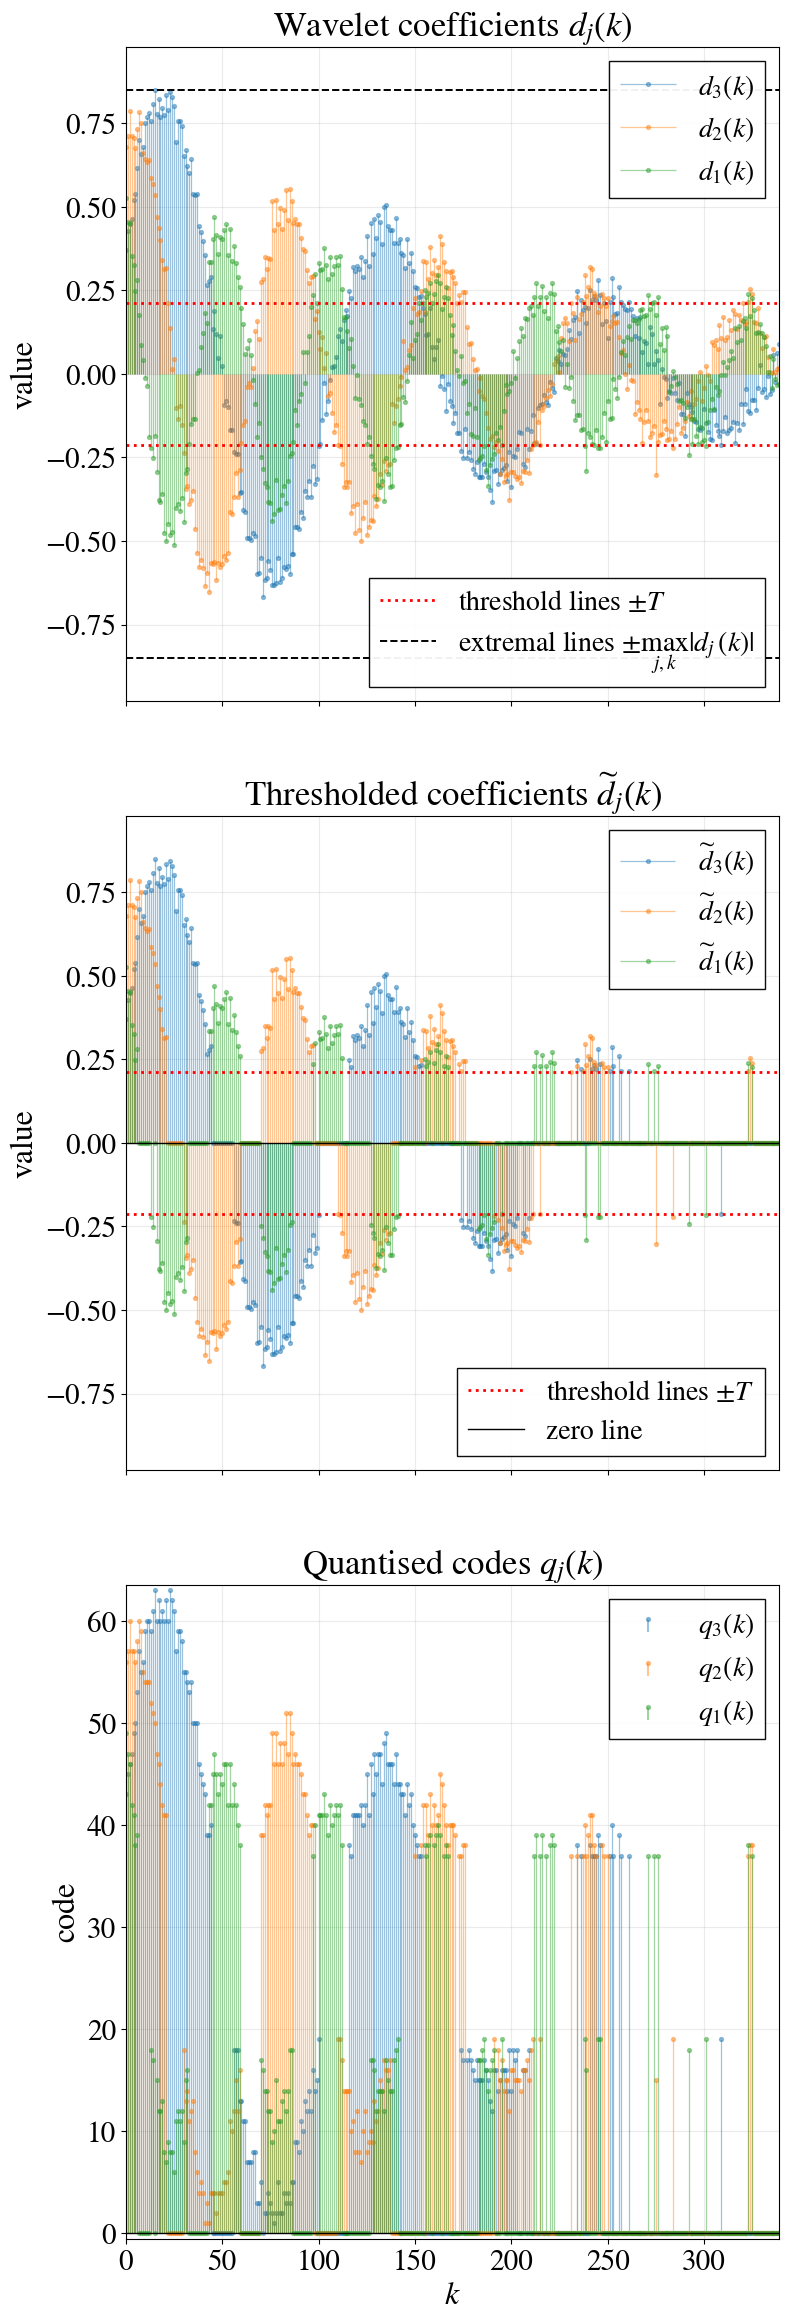

In [ ]:


plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 23,
    "axes.titlesize": 25,
    "axes.labelsize": 23,
    "xtick.labelsize": 21,
    "ytick.labelsize": 21,
    "legend.fontsize": 20,
})

def code_style_threshold_quantise(d, threshold_fraction, quant_bits):
    all_coeffs = np.concatenate([np.asarray(v, dtype=float) for v in d.values()])

    max_coeff = np.max(np.abs(all_coeffs))
    threshold_value = threshold_fraction * max_coeff

    min_val = np.min(all_coeffs)
    max_val = np.max(all_coeffs)

    quant_levels = 2 ** quant_bits
    if max_val == min_val:
        step_size = 1.0
    else:
        step_size = (max_val - min_val) / (quant_levels - 1)

    d_thresh = {}
    for j, vals in d.items():
        vals = np.asarray(vals, dtype=float)
        th = vals.copy()
        th[np.abs(th) < threshold_value] = 0.0
        d_thresh[j] = th

    d_quant = {}
    for j, vals_th in d_thresh.items():
        q = np.rint((vals_th - min_val) / step_size).astype(np.int16)
        q[vals_th == 0] = 0
        q = np.clip(q, 0, quant_levels - 1)
        d_quant[j] = q

    return d_thresh, d_quant, threshold_value, min_val, max_val, step_size, quant_levels


def add_dual_legends(ax, coeff_loc, line_loc, coeff_handles, coeff_labels, line_handles):
    coeff_legend = ax.legend(
        coeff_handles,
        coeff_labels,
        loc=coeff_loc,
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor="black"
    )
    line_legend = ax.legend(
        handles=line_handles,
        loc=line_loc,
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor="black"
    )
    ax.add_artist(coeff_legend)


def plot_three_stage_demo(d, threshold_fraction=0.35, quant_bits=6):
    js = sorted(d.keys(), reverse=True)
    n = len(next(iter(d.values())))
    k = np.arange(n)

    d_thresh, d_quant, T, min_val, max_val, step_size, quant_levels = \
        code_style_threshold_quantise(d, threshold_fraction, quant_bits)

    colours = {
        js[0]: "tab:blue",
        js[1]: "tab:orange" if len(js) > 1 else "tab:blue",
        js[2]: "tab:green" if len(js) > 2 else "tab:blue",
    }
    default_cycle = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
    for idx, j in enumerate(js):
        if j not in colours:
            colours[j] = default_cycle[idx % len(default_cycle)]

    alpha_val = 0.45
    marker_size = 2.8
    stem_width = 0.9

    raw_all = np.concatenate([np.asarray(v, dtype=float) for v in d.values()])
    raw_max = np.max(np.abs(raw_all))
    y_lim = 1.15 * raw_max

    fig, axes = plt.subplots(3, 1, figsize=(8, 24), sharex=True)

    for ax in axes:
        ax.set_box_aspect(1)

    ax = axes[0]
    coeff_handles = []
    coeff_labels = []

    for j in js:
        markerline, stemlines, baseline = ax.stem(
            k, d[j],
            linefmt='-',
            markerfmt='o',
            basefmt=' ',
            label=rf"$d_{{{j}}}(k)$"
        )
        plt.setp(markerline, color=colours[j], markersize=marker_size, alpha=alpha_val)
        plt.setp(stemlines, color=colours[j], linewidth=stem_width, alpha=alpha_val)
        coeff_handles.append((markerline, stemlines))
        coeff_labels.append(rf"$d_{{{j}}}(k)$")

    ax.axhline(T, color='red', linestyle=':', linewidth=2)
    ax.axhline(-T, color='red', linestyle=':', linewidth=2)
    ax.axhline(raw_max, color='black', linestyle='--', linewidth=1.4)
    ax.axhline(-raw_max, color='black', linestyle='--', linewidth=1.4)

    raw_line_handles = [
        Line2D([0], [0], color='red', linestyle=':', linewidth=2,
               label=r"threshold lines $\pm T$"),
        Line2D([0], [0], color='black', linestyle='--', linewidth=1.4,
               label=r"extremal lines $\pm \max_{j,k}|d_j(k)|$")
    ]

    ax.set_title(r"Wavelet coefficients $d_j(k)$")
    ax.set_ylabel("value")
    ax.set_xlim(0, n - 1)
    ax.set_ylim(-y_lim, y_lim)
    ax.grid(alpha=0.25)

    add_dual_legends(
        ax,
        coeff_loc="upper right",
        line_loc="lower right",
        coeff_handles=coeff_handles,
        coeff_labels=coeff_labels,
        line_handles=raw_line_handles
    )


    ax = axes[1]
    coeff_handles = []
    coeff_labels = []

    for j in js:
        markerline, stemlines, baseline = ax.stem(
            k, d_thresh[j],
            linefmt='-',
            markerfmt='o',
            basefmt=' ',
            label=rf"$\widetilde{{d}}_{{{j}}}(k)$"
        )
        plt.setp(markerline, color=colours[j], markersize=marker_size, alpha=alpha_val)
        plt.setp(stemlines, color=colours[j], linewidth=stem_width, alpha=alpha_val)
        coeff_handles.append((markerline, stemlines))
        coeff_labels.append(rf"$\widetilde{{d}}_{{{j}}}(k)$")

    ax.axhline(T, color='red', linestyle=':', linewidth=2)
    ax.axhline(-T, color='red', linestyle=':', linewidth=2)
    ax.axhline(0, color='black', linewidth=1)

    thresh_line_handles = [
        Line2D([0], [0], color='red', linestyle=':', linewidth=2,
               label=r"threshold lines $\pm T$"),
        Line2D([0], [0], color='black', linestyle='-', linewidth=1.0,
               label=r"zero line")
    ]

    ax.set_title(r"Thresholded coefficients $\widetilde{d}_j(k)$")
    ax.set_ylabel("value")
    ax.set_xlim(0, n - 1)
    ax.set_ylim(-y_lim, y_lim)
    ax.grid(alpha=0.25)

    add_dual_legends(
        ax,
        coeff_loc="upper right",
        line_loc="lower right",
        coeff_handles=coeff_handles,
        coeff_labels=coeff_labels,
        line_handles=thresh_line_handles
    )

    ax = axes[2]

    for j in js:
        markerline, stemlines, baseline = ax.stem(
            k, d_quant[j],
            linefmt='-',
            markerfmt='o',
            basefmt=' ',
            label=rf"$q_{{{j}}}(k)$"
        )
        plt.setp(markerline, color=colours[j], markersize=marker_size, alpha=alpha_val)
        plt.setp(stemlines, color=colours[j], linewidth=stem_width, alpha=alpha_val)

    ax.axhline(0, color='black', linewidth=1)

    ax.set_title(r"Quantised codes $q_j(k)$")
    ax.set_xlabel(r"$k$")
    ax.set_ylabel("code")
    ax.set_xlim(0, n - 1)
    ax.set_ylim(-0.5, quant_levels - 0.5)
    ax.grid(alpha=0.25)
    ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        edgecolor="black"
    )

    plt.tight_layout()
    plt.show()

k = np.arange(340)
rng = np.random.default_rng(7)

d = {
    3: 0.95 * np.exp(-k / 180) * np.sin(0.055 * k + 0.4) + 0.04 * rng.normal(size=len(k)),
    2: 0.75 * np.exp(-k / 220) * np.sin(0.080 * k + 1.1) + 0.04 * rng.normal(size=len(k)),
    1: 0.55 * np.exp(-k / 260) * np.sin(0.115 * k + 2.0) + 0.04 * rng.normal(size=len(k)),
}

plot_three_stage_demo(d, threshold_fraction=0.25, quant_bits=6)